In [26]:
# notebooks/01_eda.ipynb

# Standard libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Configure display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# For reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.0.3
NumPy version: 1.24.3


In [28]:
# Load the dataset
data_path = '../data/raw/telco_churn.csv'
df = pd.read_csv(data_path)
print(f"\nDataset loaded successfully from: {data_path}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 70)


Dataset loaded successfully from: ../data/raw/telco_churn.csv
Timestamp: 2026-03-02 19:31:02

Dataset Shape: 7,043 rows × 21 columns


In [29]:
# Display basic dataset information

df.info()

print("\n" + "=" * 70)
print("MEMORY USAGE")
print("=" * 70)
print(f"Total memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Display first few rows
print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)
display(df.head())

print("\n" + "=" * 70)
print("LAST 5 ROWS")
print("=" * 70)
display(df.tail())

print("\n" + "=" * 70)
print("RANDOM SAMPLE (5 ROWS)")
print("=" * 70)
display(df.sample(5, random_state=42))


FIRST 5 ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



LAST 5 ROWS


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No



RANDOM SAMPLE (5 ROWS)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [31]:
# Analyze columns
print("\nTotal Columns:", df.shape[1])
print("\nColumn Names and Types:")
print("-" * 70)

for idx, (col, dtype) in enumerate(df.dtypes.items(), 1):
    unique_count = df[col].nunique()
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    
    print(f"{idx:2d}. {col:20s} | Type: {str(dtype):10s} | "
          f"Unique: {unique_count:4d} | Nulls: {null_count:4d} ({null_pct:5.2f}%)")


Total Columns: 21

Column Names and Types:
----------------------------------------------------------------------
 1. customerID           | Type: object     | Unique: 7043 | Nulls:    0 ( 0.00%)
 2. gender               | Type: object     | Unique:    2 | Nulls:    0 ( 0.00%)
 3. SeniorCitizen        | Type: int64      | Unique:    2 | Nulls:    0 ( 0.00%)
 4. Partner              | Type: object     | Unique:    2 | Nulls:    0 ( 0.00%)
 5. Dependents           | Type: object     | Unique:    2 | Nulls:    0 ( 0.00%)
 6. tenure               | Type: int64      | Unique:   73 | Nulls:    0 ( 0.00%)
 7. PhoneService         | Type: object     | Unique:    2 | Nulls:    0 ( 0.00%)
 8. MultipleLines        | Type: object     | Unique:    3 | Nulls:    0 ( 0.00%)
 9. InternetService      | Type: object     | Unique:    3 | Nulls:    0 ( 0.00%)
10. OnlineSecurity       | Type: object     | Unique:    3 | Nulls:    0 ( 0.00%)
11. OnlineBackup         | Type: object     | Unique:    3 | Null


TARGET VARIABLE: Churn

Churn Distribution:
----------------------------------------------------------------------
No   : 5,174 (73.46%) ████████████████████████████████████
Yes  : 1,869 (26.54%) █████████████

Imbalance Ratio: 2.77:1
This is a MODERATELY IMBALANCED dataset


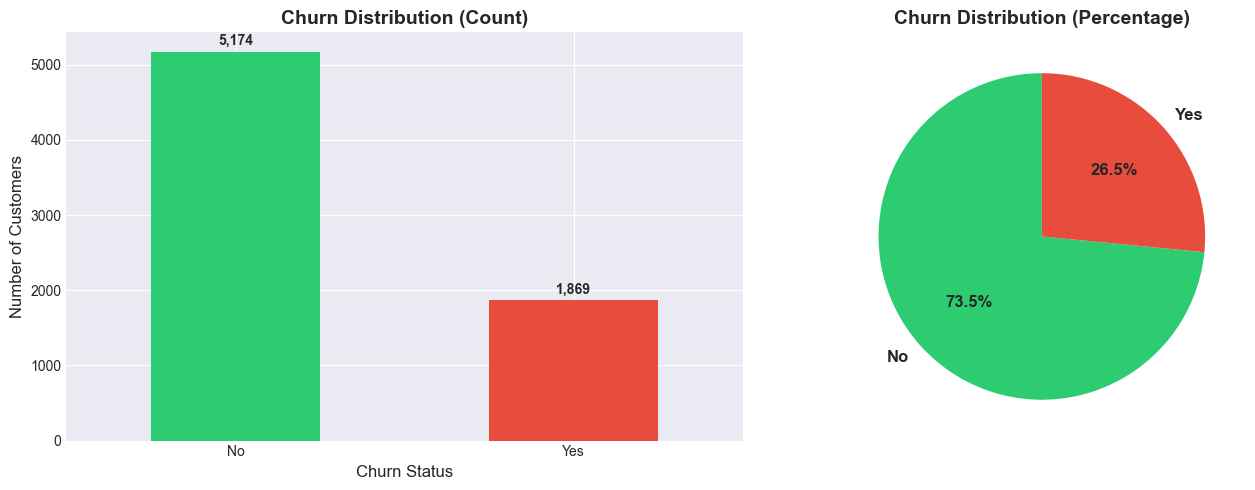


💡 Key Insight:
   - We have CLASS IMBALANCE with 73.5% non-churners vs 26.5% churners
   - This means we need to use: stratified splitting, class weights, and appropriate metrics (F1, Recall)


In [6]:
# Analyze target variable (Churn)
print("\n" + "=" * 70)
print("TARGET VARIABLE: Churn")
print("=" * 70)

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("\nChurn Distribution:")
print("-" * 70)
for status, count in churn_counts.items():
    pct = churn_pct[status]
    bar = "█" * int(pct / 2)
    print(f"{status:5s}: {count:5,d} ({pct:5.2f}%) {bar}")

# Calculate imbalance ratio
majority = churn_counts.max()
minority = churn_counts.min()
imbalance_ratio = majority / minority

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"This is a {'HIGHLY IMBALANCED' if imbalance_ratio > 3 else 'MODERATELY IMBALANCED' if imbalance_ratio > 1.5 else 'BALANCED'} dataset")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Churn Status', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
for i, v in enumerate(churn_counts.values):
    ax1.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
ax2.pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Key Insight:")
print(f"   - We have CLASS IMBALANCE with {churn_pct['No']:.1f}% non-churners vs {churn_pct['Yes']:.1f}% churners")
print(f"   - This means we need to use: stratified splitting, class weights, and appropriate metrics (F1, Recall)")

In [32]:
# Check for missing values
print("\n" + "=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df)) * 100,
    'Data_Type': df.dtypes.values
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    print(f"\n Found {len(missing_data)} column(s) with missing values:\n")
    print(missing_data.to_string(index=False))
    
    # Visualize missing values
    plt.figure(figsize=(10, 6))
    sns.barplot(data=missing_data, x='Missing_Percentage', y='Column', palette='Reds_r')
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.ylabel('Column', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No missing values found!")

print("\n" + "=" * 70)


MISSING VALUES ANALYSIS

✅ No missing values found!



In [33]:
# Data quality checks
print("\n" + "=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n1. Duplicate Rows: {duplicates}")
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows - will need to remove")
else:
    print(" No duplicates found")

# Check for constant columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"\n2. Constant Columns: {len(constant_cols)}")
if constant_cols:
    print(f"These columns have only one unique value: {constant_cols}")
else:
    print("No constant columns")

# Check customerID uniqueness
print(f"\n3. CustomerID Uniqueness:")
print(f"   Total rows: {len(df):,}")
print(f"   Unique customerIDs: {df['customerID'].nunique():,}")
if len(df) == df['customerID'].nunique():
    print("All customerIDs are unique (good for primary key)")
else:
    print("Some customerIDs are duplicated")

# Check for outliers in TotalCharges (common data quality issue)
print(f"\n4. TotalCharges Data Type Check:")
print(f"   Data type: {df['TotalCharges'].dtype}")
if df['TotalCharges'].dtype == 'object':
    print("TotalCharges is object type (should be numeric) - needs fixing!")
    # Check what values are causing this
    non_numeric = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]['TotalCharges'].unique()
    print(f"   Non-numeric values found: {non_numeric}")
else:
    print("TotalCharges is numeric")


DATA QUALITY CHECKS

1. Duplicate Rows: 0
 No duplicates found

2. Constant Columns: 0
No constant columns

3. CustomerID Uniqueness:
   Total rows: 7,043
   Unique customerIDs: 7,043
All customerIDs are unique (good for primary key)

4. TotalCharges Data Type Check:
   Data type: object
TotalCharges is object type (should be numeric) - needs fixing!
   Non-numeric values found: [' ']


In [9]:
# Statistical summary
print("\n" + "=" * 70)
print("STATISTICAL SUMMARY - NUMERICAL FEATURES")
print("=" * 70)

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Note: TotalCharges might be object type due to whitespace
# We'll convert it for summary
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print(f"\nFound {len(numerical_cols)} numerical features: {numerical_cols}\n")
display(df_temp[numerical_cols].describe().T.round(2))

# Additional statistics
print("\n" + "=" * 70)
print("ADDITIONAL STATISTICS")
print("=" * 70)

for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Range: {df_temp[col].min():.2f} to {df_temp[col].max():.2f}")
    print(f"  IQR: {df_temp[col].quantile(0.75) - df_temp[col].quantile(0.25):.2f}")
    print(f"  Skewness: {df_temp[col].skew():.2f}")
    print(f"  Kurtosis: {df_temp[col].kurtosis():.2f}")


STATISTICAL SUMMARY - NUMERICAL FEATURES

Found 3 numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']



,count,mean,std,min,25%,50%,75%,max
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.00,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80



ADDITIONAL STATISTICS

tenure:
  Range: 0.00 to 72.00
  IQR: 46.00
  Skewness: 0.24
  Kurtosis: -1.39

MonthlyCharges:
  Range: 18.25 to 118.75
  IQR: 54.35
  Skewness: -0.22
  Kurtosis: -1.26

TotalCharges:
  Range: 18.80 to 8684.80
  IQR: 3393.29
  Skewness: 0.96
  Kurtosis: -0.23


In [10]:
# Categorical features summary
print("\n" + "=" * 70)
print("CATEGORICAL FEATURES SUMMARY")
print("=" * 70)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID')  # Remove ID column

print(f"\nFound {len(categorical_cols)} categorical features\n")

for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"\n{col} ({unique_count} unique values):")
    print("-" * 50)
    
    value_counts = df[col].value_counts()
    value_pcts = df[col].value_counts(normalize=True) * 100
    
    for value, count in value_counts.items():
        pct = value_pcts[value]
        bar = "█" * int(pct / 5)
        print(f"  {str(value):20s}: {count:5,d} ({pct:5.2f}%) {bar}")


CATEGORICAL FEATURES SUMMARY

Found 17 categorical features


gender (2 unique values):
--------------------------------------------------
  Male                : 3,555 (50.48%) ██████████
  Female              : 3,488 (49.52%) █████████

Partner (2 unique values):
--------------------------------------------------
  No                  : 3,641 (51.70%) ██████████
  Yes                 : 3,402 (48.30%) █████████

Dependents (2 unique values):
--------------------------------------------------
  No                  : 4,933 (70.04%) ██████████████
  Yes                 : 2,110 (29.96%) █████

PhoneService (2 unique values):
--------------------------------------------------
  Yes                 : 6,361 (90.32%) ██████████████████
  No                  :   682 ( 9.68%) █

MultipleLines (3 unique values):
--------------------------------------------------
  No                  : 3,390 (48.13%) █████████
  Yes                 : 2,971 (42.18%) ████████
  No phone service    :   682 ( 9.68%

In [35]:
# Create data documentation
data_summary = f"""
{'='*70}
TELCO CUSTOMER CHURN - DATA SUMMARY
{'='*70}

Dataset Information:
-------------------
- Total Customers: {len(df):,}
- Total Features: {df.shape[1]}
- Target Variable: Churn (Binary: Yes/No)
- Churn Rate: {(df['Churn']=='Yes').sum() / len(df) * 100:.2f}%

Feature Types:
--------------
- Numerical Features: {len(numerical_cols)}
  - tenure (months with company)
  - MonthlyCharges (monthly bill amount)
  - TotalCharges (total amount charged)

- Categorical Features: {len(categorical_cols)}
  - Demographics: gender, SeniorCitizen, Partner, Dependents
  - Services: PhoneService, MultipleLines, InternetService, etc.
  - Account: Contract, PaymentMethod, PaperlessBilling

Data Quality Issues Found:
---------------------------
- Missing values: {'Yes' if missing_data.shape[0] > 0 else 'None'}
- Duplicates: {duplicates} rows
- TotalCharges: Object type (contains whitespace) - needs cleaning

Key Observations:
-----------------
- Class imbalance: {imbalance_ratio:.2f}:1 ratio (need stratified split & class weights)
- customerID is unique for all rows (good primary key)
- All features are relevant to churn prediction (no constant columns)

Next Steps:
-----------
1. Fix TotalCharges data type issue
2. Handle any missing values
3. Perform detailed EDA (distributions, correlations)
4. Feature engineering ideas
5. Build preprocessing pipeline

{'='*70}
"""

print(data_summary)

# Save to file
with open('../data/processed/data_summary.txt', 'w') as f:
    f.write(data_summary)
    
print("\nData summary saved to: data/processed/data_summary.txt")


TELCO CUSTOMER CHURN - DATA SUMMARY

Dataset Information:
-------------------
- Total Customers: 7,043
- Total Features: 21
- Target Variable: Churn (Binary: Yes/No)
- Churn Rate: 26.54%

Feature Types:
--------------
- Numerical Features: 3
  - tenure (months with company)
  - MonthlyCharges (monthly bill amount)
  - TotalCharges (total amount charged)

- Categorical Features: 16
  - Demographics: gender, SeniorCitizen, Partner, Dependents
  - Services: PhoneService, MultipleLines, InternetService, etc.
  - Account: Contract, PaymentMethod, PaperlessBilling

Data Quality Issues Found:
---------------------------
- Missing values: None
- Duplicates: 0 rows
- TotalCharges: Object type (contains whitespace) - needs cleaning

Key Observations:
-----------------
- Class imbalance: 2.77:1 ratio (need stratified split & class weights)
- customerID is unique for all rows (good primary key)
- All features are relevant to churn prediction (no constant columns)

Next Steps:
-----------
1. Fix T

In [36]:
# DATA CLEANING: Fix TotalCharges
print("\n" + "="*70)
print("DATA CLEANING: TotalCharges Type Conversion")
print("="*70)

# Check current state
print(f"\nBefore cleaning:")
print(f"  Data type: {df['TotalCharges'].dtype}")
print(f"  Non-null count: {df['TotalCharges'].notna().sum()}")

# Identify problematic values
print(f"\nChecking for non-numeric values...")
non_numeric_mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
non_numeric_rows = df[non_numeric_mask & df['TotalCharges'].notna()]

if len(non_numeric_rows) > 0:
    print(f"Found {len(non_numeric_rows)} rows with non-numeric values")
    print(f"\nSample problematic rows:")
    display(non_numeric_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())
    
    # Analyze these customers
    print(f"\nAnalysis of problematic rows:")
    print(f"  Average tenure: {non_numeric_rows['tenure'].mean():.2f} months")
    print(f"  All have tenure = 0? {(non_numeric_rows['tenure'] == 0).all()}")
    
    print(f"\nInsight: These are NEW CUSTOMERS (tenure=0) who haven't been billed yet")
    print(f"   Business logic: TotalCharges should be 0 for new customers")

# Convert to numeric (spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN with 0 for new customers (tenure=0)
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = 0

print(f"\nAfter cleaning:")
print(f"  Data type: {df['TotalCharges'].dtype}")
print(f"  Non-null count: {df['TotalCharges'].notna().sum()}")
print(f"  Min value: {df['TotalCharges'].min():.2f}")
print(f"  Max value: {df['TotalCharges'].max():.2f}")

print("\n" + "="*70)


DATA CLEANING: TotalCharges Type Conversion

Before cleaning:
  Data type: object
  Non-null count: 7043

Checking for non-numeric values...
Found 11 rows with non-numeric values

Sample problematic rows:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,



Analysis of problematic rows:
  Average tenure: 0.00 months
  All have tenure = 0? True

Insight: These are NEW CUSTOMERS (tenure=0) who haven't been billed yet
   Business logic: TotalCharges should be 0 for new customers

After cleaning:
  Data type: float64
  Non-null count: 7043
  Min value: 0.00
  Max value: 8684.80




NUMERICAL FEATURES ANALYSIS


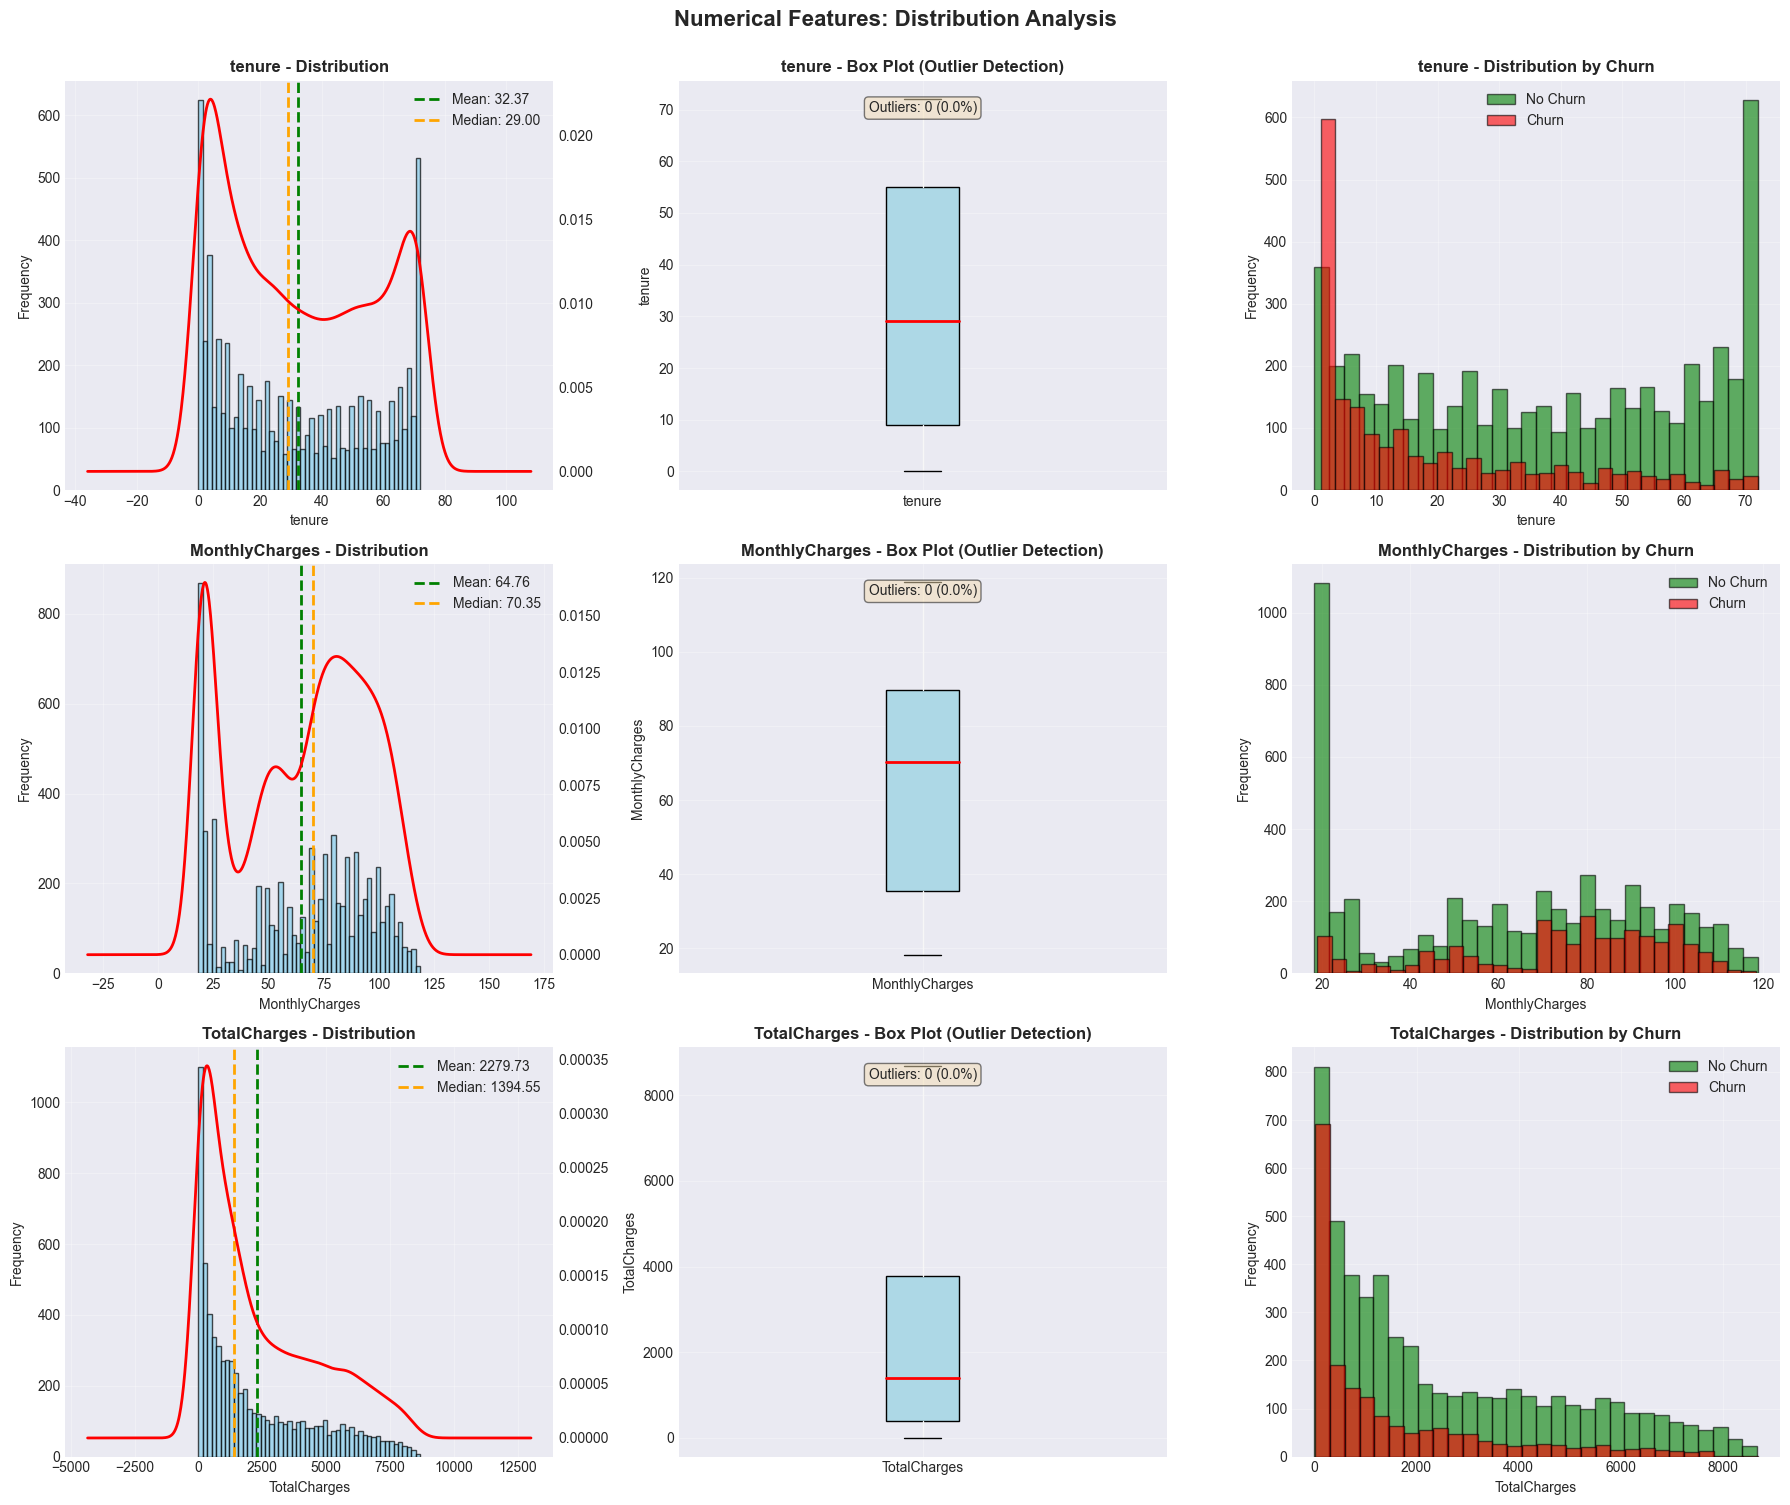


STATISTICAL SUMMARY

tenure:
--------------------------------------------------
  Range: [0.00, 72.00]
  Mean: 32.37 | Median: 29.00
  Std Dev: 24.56 (CV: 75.9%)
  Skewness: 0.24 → Fairly symmetric
  Kurtosis: -1.39 → Normal tails

  Churn vs No Churn:
    Churners: 17.98
    Non-churners: 37.57
    Difference: -52.1% → STRONG predictor!

MonthlyCharges:
--------------------------------------------------
  Range: [18.25, 118.75]
  Mean: 64.76 | Median: 70.35
  Std Dev: 30.09 (CV: 46.5%)
  Skewness: -0.22 → Fairly symmetric
  Kurtosis: -1.26 → Normal tails

  Churn vs No Churn:
    Churners: 74.44
    Non-churners: 61.27
    Difference: +21.5% → STRONG predictor!

TotalCharges:
--------------------------------------------------
  Range: [0.00, 8684.80]
  Mean: 2279.73 | Median: 1394.55
  Std Dev: 2266.79 (CV: 99.4%)
  Skewness: 0.96 → Moderately skewed
  Kurtosis: -0.23 → Normal tails

  Churn vs No Churn:
    Churners: 1531.80
    Non-churners: 2549.91
    Difference: -39.9% → STRONG 

In [37]:
# ============================================================
# NUMERICAL FEATURES: Distribution Analysis
# ============================================================

print("\n" + "="*70)
print("NUMERICAL FEATURES ANALYSIS")
print("="*70)

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create comprehensive distribution plots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Numerical Features: Distribution Analysis', fontsize=16, fontweight='bold', y=1.0)

for idx, col in enumerate(numerical_cols):
    
    # Column 1: Histogram with KDE
    ax1 = axes[idx, 0]
    df[col].hist(bins=50, ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)
    df[col].plot(kind='kde', ax=ax1, secondary_y=True, color='red', linewidth=2)
    ax1.set_title(f'{col} - Distribution', fontweight='bold')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Frequency')
    ax1.grid(alpha=0.3)
    
    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax1.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    ax1.legend(loc='upper right')
    
    # Column 2: Box plot
    ax2 = axes[idx, 1]
    df.boxplot(column=col, ax=ax2, patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
    ax2.set_title(f'{col} - Box Plot (Outlier Detection)', fontweight='bold')
    ax2.set_ylabel(col)
    ax2.grid(alpha=0.3)
    
    # Calculate outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    outlier_pct = (len(outliers) / len(df)) * 100
    ax2.text(0.5, 0.95, f'Outliers: {len(outliers)} ({outlier_pct:.1f}%)', 
             transform=ax2.transAxes, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Column 3: Distribution by Churn
    ax3 = axes[idx, 2]
    df[df['Churn']=='No'][col].hist(bins=30, ax=ax3, alpha=0.6, color='green', label='No Churn', edgecolor='black')
    df[df['Churn']=='Yes'][col].hist(bins=30, ax=ax3, alpha=0.6, color='red', label='Churn', edgecolor='black')
    ax3.set_title(f'{col} - Distribution by Churn', fontweight='bold')
    ax3.set_xlabel(col)
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary with interpretation
print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)

for col in numerical_cols:
    print(f"\n{col}:")
    print("-" * 50)
    
    stats = df[col].describe()
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    print(f"  Range: [{stats['min']:.2f}, {stats['max']:.2f}]")
    print(f"  Mean: {stats['mean']:.2f} | Median: {stats['50%']:.2f}")
    print(f"  Std Dev: {stats['std']:.2f} (CV: {(stats['std']/stats['mean']*100):.1f}%)")
    print(f"  Skewness: {skew:.2f}", end="")
    
    if abs(skew) < 0.5:
        print(" → Fairly symmetric")
    elif abs(skew) < 1:
        print(" → Moderately skewed")
    else:
        print(" → Highly skewed (consider transformation)")
    
    print(f"  Kurtosis: {kurt:.2f}", end="")
    if kurt > 3:
        print(" → Heavy tails (many outliers)")
    else:
        print(" → Normal tails")
    
    # Churn comparison
    churn_mean = df[df['Churn']=='Yes'][col].mean()
    no_churn_mean = df[df['Churn']=='No'][col].mean()
    diff_pct = ((churn_mean - no_churn_mean) / no_churn_mean) * 100
    
    print(f"\n  Churn vs No Churn:")
    print(f"    Churners: {churn_mean:.2f}")
    print(f"    Non-churners: {no_churn_mean:.2f}")
    print(f"    Difference: {diff_pct:+.1f}%", end="")
    
    if abs(diff_pct) > 20:
        print(" → STRONG predictor!")
    elif abs(diff_pct) > 10:
        print(" → Moderate predictor")
    else:
        print(" → Weak predictor")


TENURE ANALYSIS: Customer Lifecycle Patterns

Churn Rate by Tenure Group:
--------------------------------------------------
  0-1 year    : 47.68% ███████████████████████
  1-2 years   : 28.71% ██████████████
  2-4 years   : 20.39% ██████████
  4+ years    :  9.51% ████


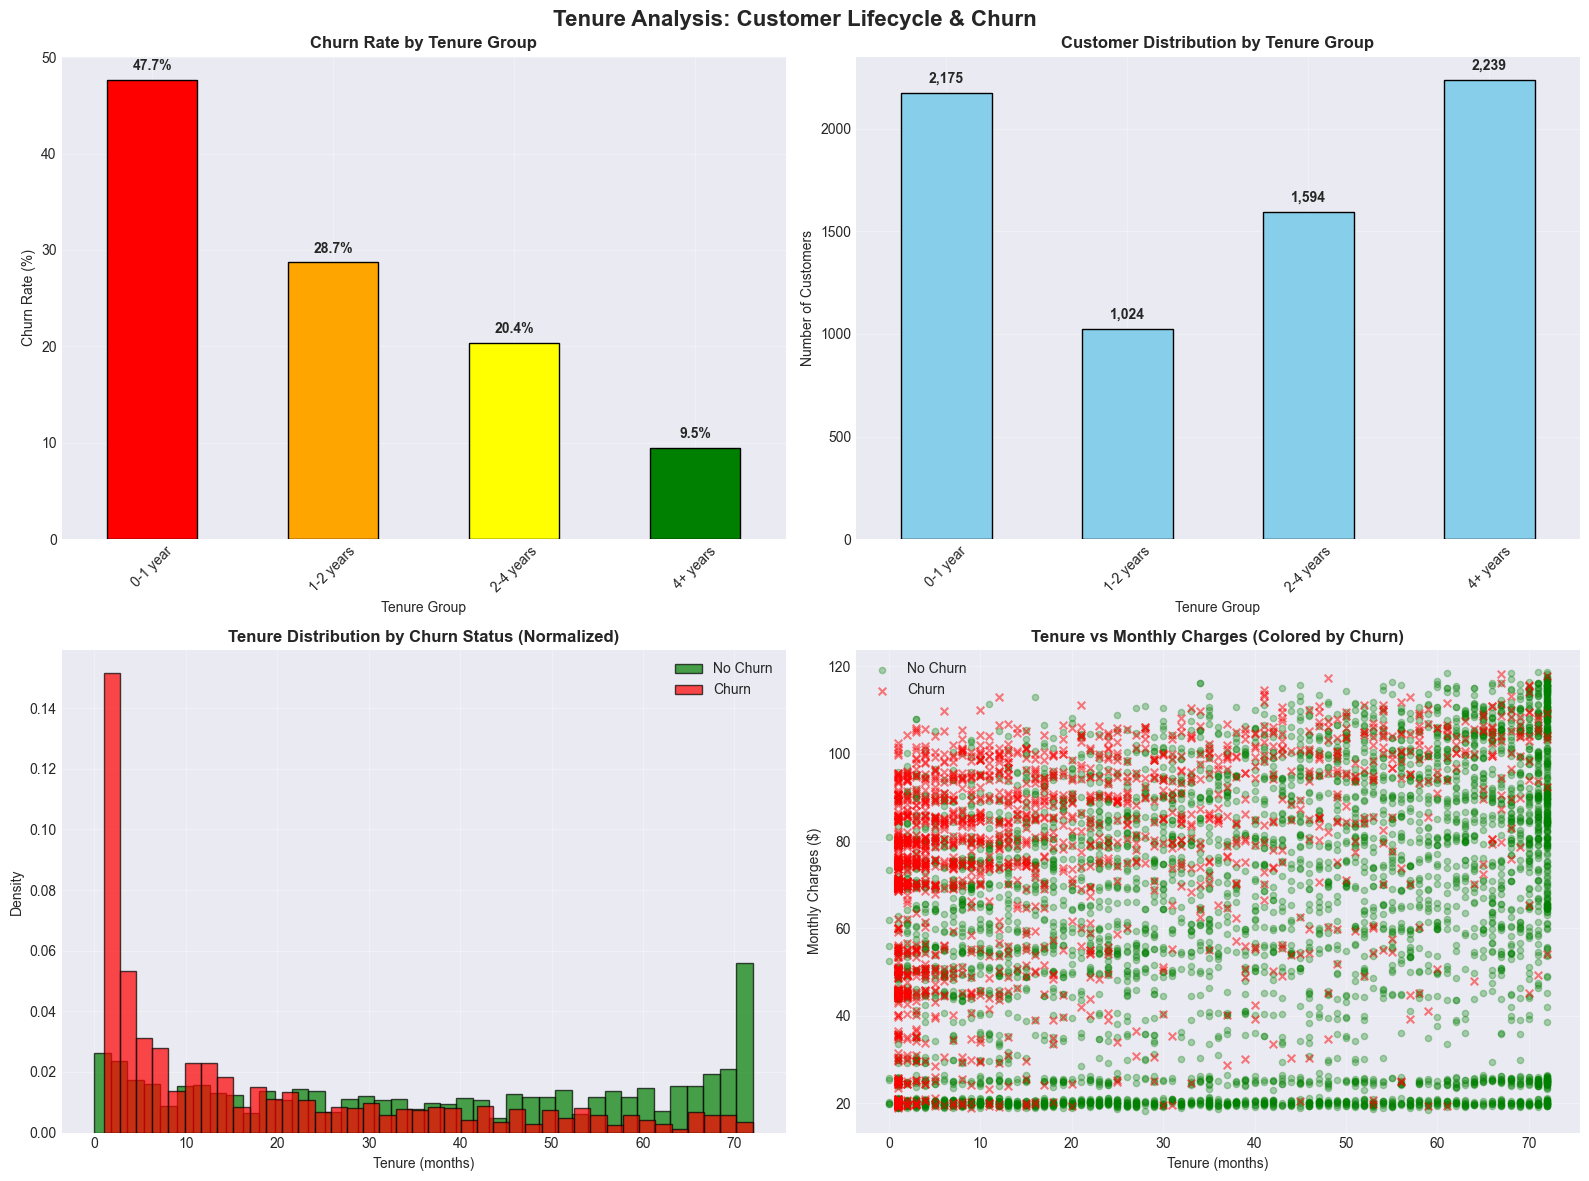


KEY INSIGHTS - Tenure:
--------------------------------------------------
  1. New customers (0-1 year) have 47.7% churn rate - HIGHEST RISK!
  2. Long-term customers (4+ years) have 9.5% churn rate - most loyal
  3. First year is CRITICAL for retention
  4. Churn risk drops significantly after 2 years


In [38]:
# ============================================================
# DEEPER NUMERICAL ANALYSIS: Tenure Patterns
# ============================================================

print("\n" + "="*70)
print("TENURE ANALYSIS: Customer Lifecycle Patterns")
print("="*70)

# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-1 year', '1-2 years', '2-4 years', '4+ years'])

# Analyze churn by tenure group
tenure_churn = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).round(2)

print("\nChurn Rate by Tenure Group:")
print("-" * 50)
for group, rate in tenure_churn.items():
    bar = "█" * int(rate / 2)
    print(f"  {group:12s}: {rate:5.2f}% {bar}")

# Visualize tenure patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tenure Analysis: Customer Lifecycle & Churn', fontsize=16, fontweight='bold')

# Plot 1: Churn rate by tenure group
ax1 = axes[0, 0]
tenure_churn.plot(kind='bar', ax=ax1, color=['red', 'orange', 'yellow', 'green'], edgecolor='black')
ax1.set_title('Churn Rate by Tenure Group', fontweight='bold', fontsize=12)
ax1.set_xlabel('Tenure Group')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.grid(alpha=0.3)
for i, v in enumerate(tenure_churn.values):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 2: Customer count by tenure group
ax2 = axes[0, 1]
tenure_counts = df['tenure_group'].value_counts().sort_index()
tenure_counts.plot(kind='bar', ax=ax2, color='skyblue', edgecolor='black')
ax2.set_title('Customer Distribution by Tenure Group', fontweight='bold', fontsize=12)
ax2.set_xlabel('Tenure Group')
ax2.set_ylabel('Number of Customers')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.grid(alpha=0.3)
for i, v in enumerate(tenure_counts.values):
    ax2.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Plot 3: Tenure distribution by churn status
ax3 = axes[1, 0]
df[df['Churn']=='No']['tenure'].hist(bins=40, ax=ax3, alpha=0.7, color='green', 
                                       label='No Churn', edgecolor='black', density=True)
df[df['Churn']=='Yes']['tenure'].hist(bins=40, ax=ax3, alpha=0.7, color='red', 
                                        label='Churn', edgecolor='black', density=True)
ax3.set_title('Tenure Distribution by Churn Status (Normalized)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Tenure (months)')
ax3.set_ylabel('Density')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: MonthlyCharges vs Tenure scatter plot
ax4 = axes[1, 1]
no_churn = df[df['Churn']=='No']
churn = df[df['Churn']=='Yes']
ax4.scatter(no_churn['tenure'], no_churn['MonthlyCharges'], 
           alpha=0.3, s=20, c='green', label='No Churn')
ax4.scatter(churn['tenure'], churn['MonthlyCharges'], 
           alpha=0.5, s=30, c='red', label='Churn', marker='x')
ax4.set_title('Tenure vs Monthly Charges (Colored by Churn)', fontweight='bold', fontsize=12)
ax4.set_xlabel('Tenure (months)')
ax4.set_ylabel('Monthly Charges ($)')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKEY INSIGHTS - Tenure:")
print("-" * 50)
print(f"  1. New customers (0-1 year) have {tenure_churn.iloc[0]:.1f}% churn rate - HIGHEST RISK!")
print(f"  2. Long-term customers (4+ years) have {tenure_churn.iloc[-1]:.1f}% churn rate - most loyal")
print(f"  3. First year is CRITICAL for retention")
print(f"  4. Churn risk drops significantly after 2 years")

In [39]:
# ============================================================
# CATEGORICAL FEATURES: Churn Rate Analysis
# ============================================================

print("\n" + "="*70)
print("CATEGORICAL FEATURES: Churn Rate by Category")
print("="*70)

# Select categorical features (exclude customerID and Churn)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

# Also add SeniorCitizen (currently int but should be categorical)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
categorical_cols.insert(0, 'SeniorCitizen')

# Calculate churn rate for each category
churn_rates = {}

for col in categorical_cols:
    churn_by_cat = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)
    churn_rates[col] = churn_by_cat

# Display top insights
print("\nHIGH-RISK CATEGORIES (>50% churn rate):")
print("-" * 70)

high_risk_found = False
for col, rates in churn_rates.items():
    high_risk = rates[rates > 50]
    if len(high_risk) > 0:
        high_risk_found = True
        print(f"\n  {col}:")
        for category, rate in high_risk.items():
            count = len(df[(df[col]==category)])
            print(f"    • {str(category):25s}: {rate:5.1f}% churn ({count:,} customers)")

if not high_risk_found:
    print("  No categories with >50% churn rate")

print("\nLOW-RISK CATEGORIES (<15% churn rate):")
print("-" * 70)

low_risk_found = False
for col, rates in churn_rates.items():
    low_risk = rates[rates < 15]
    if len(low_risk) > 0:
        low_risk_found = True
        print(f"\n  {col}:")
        for category, rate in low_risk.items():
            count = len(df[(df[col]==category)])
            print(f"    • {str(category):25s}: {rate:5.1f}% churn ({count:,} customers)")

if not low_risk_found:
    print("  No categories with <15% churn rate")


CATEGORICAL FEATURES: Churn Rate by Category

HIGH-RISK CATEGORIES (>50% churn rate):
----------------------------------------------------------------------
  No categories with >50% churn rate

LOW-RISK CATEGORIES (<15% churn rate):
----------------------------------------------------------------------

  InternetService:
    • No                       :   7.4% churn (1,526 customers)

  OnlineSecurity:
    • Yes                      :  14.6% churn (2,019 customers)
    • No internet service      :   7.4% churn (1,526 customers)

  OnlineBackup:
    • No internet service      :   7.4% churn (1,526 customers)

  DeviceProtection:
    • No internet service      :   7.4% churn (1,526 customers)

  TechSupport:
    • No internet service      :   7.4% churn (1,526 customers)

  StreamingTV:
    • No internet service      :   7.4% churn (1,526 customers)

  StreamingMovies:
    • No internet service      :   7.4% churn (1,526 customers)

  Contract:
    • One year                 :  11.3% 

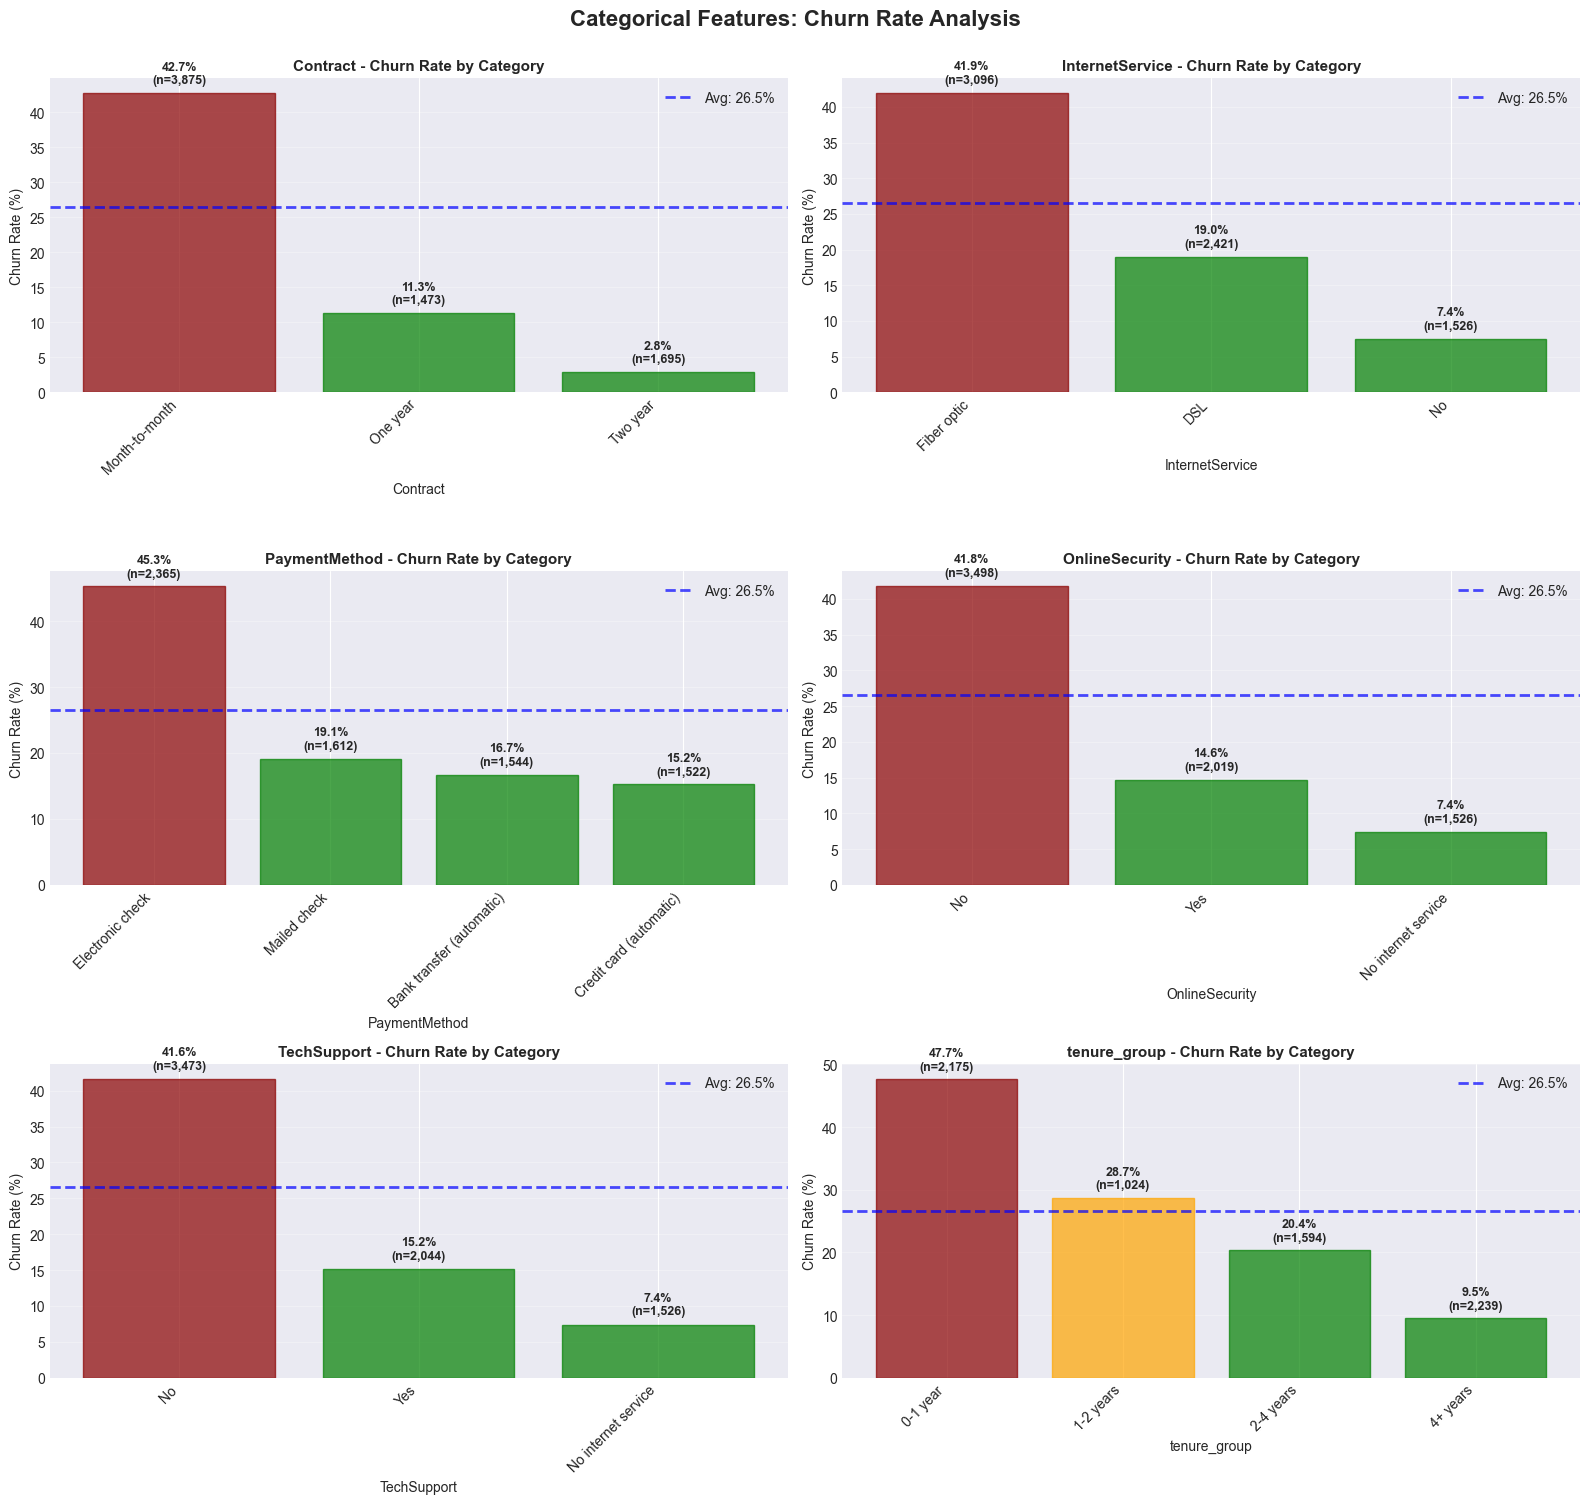

In [17]:
# ============================================================
# CATEGORICAL FEATURES: Visual Analysis
# ============================================================

# Select top features with highest churn variance
features_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 
                    'OnlineSecurity', 'TechSupport', 'tenure_group']

n_features = len(features_to_plot)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
axes = axes.flatten()
fig.suptitle('Categorical Features: Churn Rate Analysis', fontsize=16, fontweight='bold', y=1.0)

for idx, col in enumerate(features_to_plot):
    ax = axes[idx]
    
    # Calculate churn rate and total count for each category
    churn_data = df.groupby(col).agg({
        'Churn': [
            lambda x: (x=='Yes').sum(),  # Churn count
            'count',  # Total count
            lambda x: (x=='Yes').sum() / len(x) * 100  # Churn rate
        ]
    }).round(2)
    
    churn_data.columns = ['Churn_Count', 'Total_Count', 'Churn_Rate']
    churn_data = churn_data.sort_values('Churn_Rate', ascending=False)
    
    # Create bar plot
    x_pos = np.arange(len(churn_data))
    bars = ax.bar(x_pos, churn_data['Churn_Rate'], color='coral', edgecolor='black', alpha=0.7)
    
    # Color code: red for high churn, green for low churn
    colors = ['darkred' if rate > 40 else 'orange' if rate > 25 else 'green' 
              for rate in churn_data['Churn_Rate']]
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    ax.set_title(f'{col} - Churn Rate by Category', fontweight='bold', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(churn_data.index, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels and sample size
    for i, (rate, count) in enumerate(zip(churn_data['Churn_Rate'], churn_data['Total_Count'])):
        ax.text(i, rate + 1, f'{rate:.1f}%\n(n={count:,})', 
               ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add average churn rate line
    avg_churn = (df['Churn']=='Yes').mean() * 100
    ax.axhline(avg_churn, color='blue', linestyle='--', linewidth=2, 
              label=f'Avg: {avg_churn:.1f}%', alpha=0.7)
    ax.legend(loc='upper right')

# Remove empty subplots
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


FEATURE IMPORTANCE INDICATOR

Note: This is a preliminary assessment based on churn rate variance.
Actual feature importance will be calculated during model training.

Top 10 Most Important Categorical Features (by churn rate variance):
----------------------------------------------------------------------
Feature                     Variance      Range   Importance
----------------------------------------------------------------------
 1. Contract                   0.0442       0.40       2.41 █
 2. OnlineSecurity             0.0328       0.34       1.81 
 3. TechSupport                0.0322       0.34       1.78 
 4. InternetService            0.0308       0.34       1.71 
 5. OnlineBackup               0.0266       0.33       1.49 
 6. DeviceProtection           0.0252       0.32       1.42 
 7. PaymentMethod              0.0202       0.30       1.16 
 8. StreamingMovies            0.0202       0.26       1.14 
 9. StreamingTV                0.0201       0.26       1.14 
10. Senio

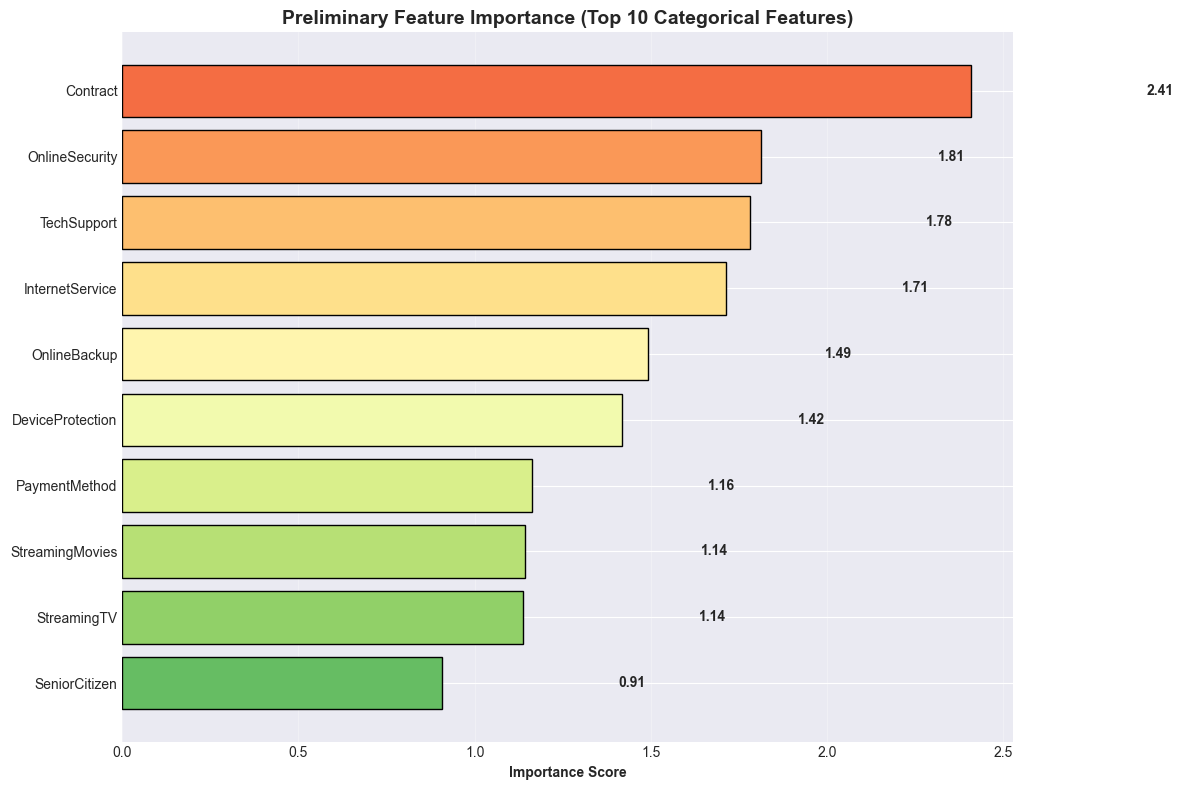


INSIGHT: These features show the highest variance in churn rates,
   suggesting they may be strong predictors in our model.


In [40]:
# ============================================================
# FEATURE IMPORTANCE INDICATOR (Before Modeling)
# ============================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE INDICATOR")
print("="*70)
print("\nNote: This is a preliminary assessment based on churn rate variance.")
print("Actual feature importance will be calculated during model training.\n")

# Calculate importance score for categorical features
importance_scores = {}

for col in categorical_cols:
    # Variance in churn rates across categories
    churn_by_cat = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').sum() / len(x)
    )
    
    # Higher variance = more discriminative feature
    variance = churn_by_cat.var()
    
    # Range of churn rates
    rate_range = churn_by_cat.max() - churn_by_cat.min()
    
    # Combined score (normalized)
    importance_scores[col] = {
        'variance': variance,
        'range': rate_range,
        'score': (variance * 100 + rate_range) / 2  # Combined metric
    }

# Sort by importance
importance_df = pd.DataFrame(importance_scores).T.sort_values('score', ascending=False)

print("Top 10 Most Important Categorical Features (by churn rate variance):")
print("-" * 70)
print(f"{'Feature':<25} {'Variance':>10} {'Range':>10} {'Importance':>12}")
print("-" * 70)

for idx, (feature, row) in enumerate(importance_df.head(10).iterrows(), 1):
    bar = "█" * int(row['score'] / 2)
    print(f"{idx:2d}. {feature:<22} {row['variance']:>10.4f} {row['range']:>10.2f} {row['score']:>10.2f} {bar}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
top_features = importance_df.head(10).sort_values('score')
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_features)))

bars = ax.barh(range(len(top_features)), top_features['score'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Preliminary Feature Importance (Top 10 Categorical Features)', 
            fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (score, feature) in enumerate(zip(top_features['score'], top_features.index)):
    ax.text(score + 0.5, i, f'{score:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nINSIGHT: These features show the highest variance in churn rates,")
print("   suggesting they may be strong predictors in our model.")


CORRELATION ANALYSIS


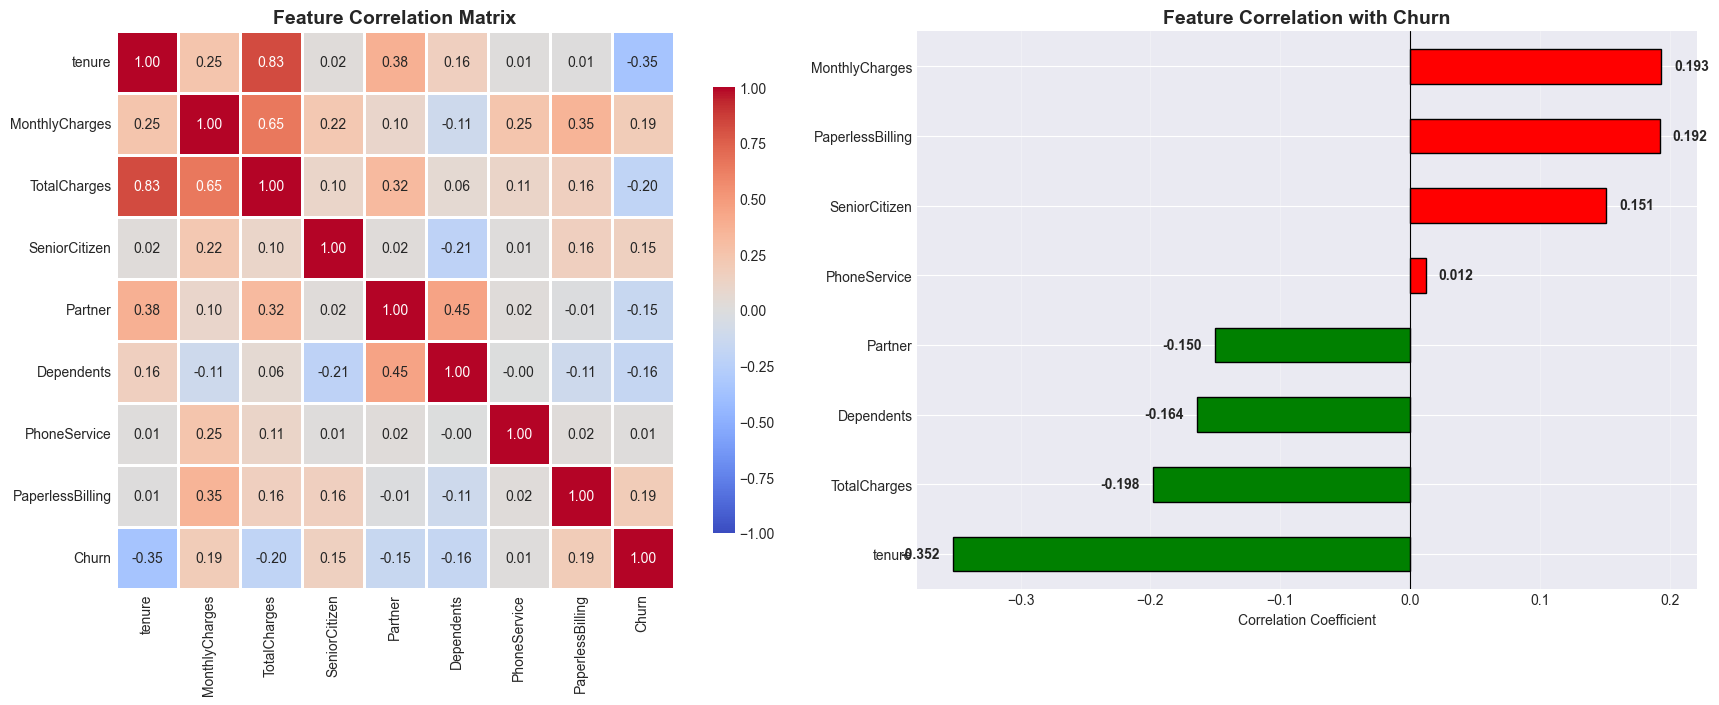


Top Correlations with Churn:
--------------------------------------------------
  1. tenure              : -0.352 (negative)
  2. TotalCharges        : -0.198 (negative)
  3. MonthlyCharges      : +0.193 (positive)
  4. PaperlessBilling    : +0.192 (positive)
  5. Dependents          : -0.164 (negative)

INTERPRETATION:
  • Positive correlation: Higher value → Higher churn
  • Negative correlation: Higher value → Lower churn
  • |r| > 0.3: Strong relationship
  • |r| < 0.1: Weak relationship

 MULTICOLLINEARITY CHECK:
--------------------------------------------------
Features with high correlation (|r| > 0.7, excluding Churn):
  • tenure <-> TotalCharges: 0.826

High correlation detected! May need to drop one feature.


In [41]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

# Create numerical encoding for correlation analysis
df_corr = df.copy()

# Encode binary features
binary_mappings = {
    'gender': {'Male': 1, 'Female': 0},
    'SeniorCitizen': {'Yes': 1, 'No': 0},
    'Partner': {'Yes': 1, 'No': 0},
    'Dependents': {'Yes': 1, 'No': 0},
    'PhoneService': {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0},
    'Churn': {'Yes': 1, 'No': 0}
}

for col, mapping in binary_mappings.items():
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].map(mapping)

# Select features for correlation
corr_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                'SeniorCitizen', 'Partner', 'Dependents', 
                'PhoneService', 'PaperlessBilling', 'Churn']

# Calculate correlation matrix
correlation_matrix = df_corr[corr_features].corr()

# Visualize correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Full correlation matrix
ax1 = axes[0]
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
           ax=ax1, vmin=-1, vmax=1)
ax1.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)

# Plot 2: Correlation with Churn (sorted)
ax2 = axes[1]
churn_corr = correlation_matrix['Churn'].drop('Churn').sort_values(ascending=True)
colors = ['green' if x < 0 else 'red' for x in churn_corr]
churn_corr.plot(kind='barh', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Feature Correlation with Churn', fontweight='bold', fontsize=14)
ax2.set_xlabel('Correlation Coefficient')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(churn_corr.values):
    ax2.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
            va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

# Print strongest correlations
print("\nTop Correlations with Churn:")
print("-" * 50)
churn_corr_abs = correlation_matrix['Churn'].drop('Churn').abs().sort_values(ascending=False)

for idx, (feature, corr) in enumerate(churn_corr_abs.head(5).items(), 1):
    actual_corr = correlation_matrix.loc[feature, 'Churn']
    direction = "positive" if actual_corr > 0 else "negative"
    print(f"  {idx}. {feature:20s}: {actual_corr:+.3f} ({direction})")

print("\nINTERPRETATION:")
print(f"  • Positive correlation: Higher value → Higher churn")
print(f"  • Negative correlation: Higher value → Lower churn")
print(f"  • |r| > 0.3: Strong relationship")
print(f"  • |r| < 0.1: Weak relationship")

# Check multicollinearity
print("\n MULTICOLLINEARITY CHECK:")
print("-" * 50)
print("Features with high correlation (|r| > 0.7, excluding Churn):")

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            if correlation_matrix.columns[i] != 'Churn' and correlation_matrix.columns[j] != 'Churn':
                high_corr_pairs.append((
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    correlation_matrix.iloc[i, j]
                ))

if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  • {feat1} <-> {feat2}: {corr:.3f}")
    print("\nHigh correlation detected! May need to drop one feature.")
else:
    print("No severe multicollinearity detected")

In [42]:
# ============================================================
# KEY BUSINESS INSIGHTS & PATTERNS
# ============================================================

print("\n" + "="*70)
print("KEY BUSINESS INSIGHTS FROM EDA")
print("="*70)

# Calculate key metrics
total_customers = len(df)
churned_customers = (df['Churn']=='Yes').sum()
churn_rate = churned_customers / total_customers * 100
avg_monthly_charge = df['MonthlyCharges'].mean()
monthly_revenue_loss = churned_customers * avg_monthly_charge
annual_revenue_loss = monthly_revenue_loss * 12

print(f"\nOVERALL METRICS:")
print("-" * 70)
print(f"  Total Customers: {total_customers:,}")
print(f"  Churned Customers: {churned_customers:,}")
print(f"  Churn Rate: {churn_rate:.2f}%")
print(f"  Average Monthly Charge: ${avg_monthly_charge:.2f}")
print(f"  Estimated Monthly Revenue Loss: ${monthly_revenue_loss:,.2f}")
print(f"  Estimated Annual Revenue Loss: ${annual_revenue_loss:,.2f}")

print(f"\nTOP CHURN RISK FACTORS:")
print("-" * 70)

risk_factors = []

# Contract type
month_to_month_churn = (df[df['Contract']=='Month-to-month']['Churn']=='Yes').mean() * 100
risk_factors.append(('Month-to-month contract', month_to_month_churn))

# Internet service
fiber_churn = (df[df['InternetService']=='Fiber optic']['Churn']=='Yes').mean() * 100
risk_factors.append(('Fiber optic internet', fiber_churn))

# Payment method
electronic_check_churn = (df[df['PaymentMethod']=='Electronic check']['Churn']=='Yes').mean() * 100
risk_factors.append(('Electronic check payment', electronic_check_churn))

# No support services
no_tech_support_churn = (df[df['TechSupport']=='No']['Churn']=='Yes').mean() * 100
risk_factors.append(('No tech support', no_tech_support_churn))

# New customers
new_customer_churn = (df[df['tenure'] <= 12]['Churn']=='Yes').mean() * 100
risk_factors.append(('Tenure ≤ 1 year', new_customer_churn))

# Sort and display
risk_factors.sort(key=lambda x: x[1], reverse=True)
for idx, (factor, rate) in enumerate(risk_factors, 1):
    print(f"  {idx}. {factor:30s}: {rate:5.1f}% churn rate")

print(f"\nPROTECTIVE FACTORS (Low Churn):")
print("-" * 70)

protective_factors = []

# Long-term contract
two_year_churn = (df[df['Contract']=='Two year']['Churn']=='Yes').mean() * 100
protective_factors.append(('Two-year contract', two_year_churn))

# Loyal customers
loyal_churn = (df[df['tenure'] > 48]['Churn']=='Yes').mean() * 100
protective_factors.append(('Tenure > 4 years', loyal_churn))

# Tech support
has_tech_support_churn = (df[df['TechSupport']=='Yes']['Churn']=='Yes').mean() * 100
protective_factors.append(('Has tech support', has_tech_support_churn))

# Sort and display
protective_factors.sort(key=lambda x: x[1])
for idx, (factor, rate) in enumerate(protective_factors, 1):
    print(f"  {idx}. {factor:30s}: {rate:5.1f}% churn rate")

print(f"\nACTIONABLE RECOMMENDATIONS:")
print("-" * 70)
print(f"  1. RETENTION FOCUS: Target month-to-month customers in first year")
print(f"     → These have {month_to_month_churn:.1f}% churn rate vs {churn_rate:.1f}% average")
print(f"")
print(f"  2. CONTRACT INCENTIVES: Encourage long-term contracts")
print(f"     → Two-year contracts have {two_year_churn:.1f}% churn vs {month_to_month_churn:.1f}% month-to-month")
print(f"     → Potential savings: {(month_to_month_churn - two_year_churn):.1f} percentage points")
print(f"")
print(f"  3. SERVICE BUNDLE: Promote tech support and online security")
print(f"     → Customers with tech support have {has_tech_support_churn:.1f}% churn vs {no_tech_support_churn:.1f}% without")
print(f"")
print(f"  4. PAYMENT METHOD: Investigate electronic check issues")
print(f"     → {electronic_check_churn:.1f}% churn rate suggests payment friction")
print(f"")
print(f"  5. NEW CUSTOMER ONBOARDING: Critical first 12 months")
print(f"     → {new_customer_churn:.1f}% churn in first year - needs improved onboarding")

print(f"\n BUSINESS IMPACT OF ML MODEL:")
print("-" * 70)
print(f"  If model achieves 80% recall:")
print(f"    • Identify: {churned_customers * 0.8:.0f} out of {churned_customers} potential churners")
print(f"    • If 50% can be saved with $50 retention offer:")
print(f"      - Cost: ${churned_customers * 0.8 * 0.5 * 50:,.2f}")
print(f"      - Revenue saved: ${churned_customers * 0.8 * 0.5 * avg_monthly_charge * 12:,.2f} (annual)")
print(f"      - Net benefit: ${(churned_customers * 0.8 * 0.5 * avg_monthly_charge * 12) - (churned_customers * 0.8 * 0.5 * 50):,.2f}")


KEY BUSINESS INSIGHTS FROM EDA

OVERALL METRICS:
----------------------------------------------------------------------
  Total Customers: 7,043
  Churned Customers: 1,869
  Churn Rate: 26.54%
  Average Monthly Charge: $64.76
  Estimated Monthly Revenue Loss: $121,039.60
  Estimated Annual Revenue Loss: $1,452,475.24

TOP CHURN RISK FACTORS:
----------------------------------------------------------------------
  1. Tenure ≤ 1 year               :  47.4% churn rate
  2. Electronic check payment      :  45.3% churn rate
  3. Month-to-month contract       :  42.7% churn rate
  4. Fiber optic internet          :  41.9% churn rate
  5. No tech support               :  41.6% churn rate

PROTECTIVE FACTORS (Low Churn):
----------------------------------------------------------------------
  1. Two-year contract             :   2.8% churn rate
  2. Tenure > 4 years              :   9.5% churn rate
  3. Has tech support              :  15.2% churn rate

ACTIONABLE RECOMMENDATIONS:
-----------

In [21]:
# ============================================================
# FEATURE ENGINEERING IDEAS FROM EDA
# ============================================================

print("\n" + "="*70)
print("FEATURE ENGINEERING IDEAS")
print("="*70)

print("\nBased on EDA insights, here are potential new features to create:")
print("-" * 70)

print("\n1. TENURE-BASED FEATURES:")
print("  • is_new_customer (tenure <= 12 months)")
print("  • is_loyal_customer (tenure > 48 months)")
print("  • tenure_group (categorical: 0-1yr, 1-2yr, 2-4yr, 4+yr)")
print("  Rationale: Strong churn pattern in first year")

print("\n2. CHARGES-BASED FEATURES:")
print("  • charges_per_month_tenure (TotalCharges / tenure)")
print("  • high_monthly_charge (MonthlyCharges > $70)")
print("  • price_increase_indicator (if TotalCharges/tenure > MonthlyCharges)")
print("  Rationale: High charges correlate with churn")

print("\n3. SERVICE BUNDLE FEATURES:")
print("  • total_services (count of subscribed services)")
print("  • has_protection (OnlineSecurity OR OnlineBackup)")
print("  • has_support (TechSupport OR DeviceProtection)")
print("  • service_coverage_score (percentage of available services)")
print("  Rationale: Service adoption affects loyalty")

print("\n4. CONTRACT & PAYMENT FEATURES:")
print("  • is_monthly_contract (Month-to-month = 1)")
print("  • automatic_payment (Bank transfer OR Credit card)")
print("  • risky_payment_method (Electronic check = 1)")
print("  Rationale: Strong predictors identified in EDA")

print("\n5. INTERACTION FEATURES:")
print("  • tenure_contract_interaction (tenure * Contract encoding)")
print("  • charges_service_interaction (MonthlyCharges * total_services)")
print("  • senior_charges_interaction (SeniorCitizen * MonthlyCharges)")
print("  Rationale: Combined effects may be stronger than individual")

print("\n6. DEMOGRAPHIC FEATURES:")
print("  • family_size (Partner + Dependents)")
print("  • senior_with_dependents (SeniorCitizen AND Dependents)")
print("  Rationale: Household composition affects stability")

print("\n" + "="*70)
print("These features will be implemented in the preprocessing pipeline.")
print("="*70)


FEATURE ENGINEERING IDEAS

Based on EDA insights, here are potential new features to create:
----------------------------------------------------------------------

1. TENURE-BASED FEATURES:
  • is_new_customer (tenure <= 12 months)
  • is_loyal_customer (tenure > 48 months)
  • tenure_group (categorical: 0-1yr, 1-2yr, 2-4yr, 4+yr)
  Rationale: Strong churn pattern in first year

2. CHARGES-BASED FEATURES:
  • charges_per_month_tenure (TotalCharges / tenure)
  • high_monthly_charge (MonthlyCharges > $70)
  • price_increase_indicator (if TotalCharges/tenure > MonthlyCharges)
  Rationale: High charges correlate with churn

3. SERVICE BUNDLE FEATURES:
  • total_services (count of subscribed services)
  • has_protection (OnlineSecurity OR OnlineBackup)
  • has_support (TechSupport OR DeviceProtection)
  • service_coverage_score (percentage of available services)
  Rationale: Service adoption affects loyalty

4. CONTRACT & PAYMENT FEATURES:
  • is_monthly_contract (Month-to-month = 1)
  • 

In [43]:
# ============================================================
# SAVE EDA SUMMARY
# ============================================================

# Create comprehensive EDA summary
eda_summary = f"""
{'='*70}
TELCO CUSTOMER CHURN - EDA SUMMARY REPORT
{'='*70}

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Analyst: Your Name
Project: Customer Churn Prediction MLOps Pipeline

{'='*70}
1. DATASET OVERVIEW
{'='*70}

Total Customers: {len(df):,}
Churned Customers: {(df['Churn']=='Yes').sum():,} ({(df['Churn']=='Yes').mean()*100:.2f}%)
Non-Churned Customers: {(df['Churn']=='No').sum():,} ({(df['Churn']=='No').mean()*100:.2f}%)

Imbalance Ratio: {(df['Churn']=='No').sum() / (df['Churn']=='Yes').sum():.2f}:1

Features:
  - Numerical: 3 (tenure, MonthlyCharges, TotalCharges)
  - Categorical: 17 (demographics, services, account info)
  - Target: Churn (Binary: Yes/No)

{'='*70}
2. DATA QUALITY
{'='*70}

No duplicate rows
No missing values (after cleaning TotalCharges)
All customerIDs unique
TotalCharges data type issue fixed (whitespace → 0 for new customers)

{'='*70}
3. KEY FINDINGS
{'='*70}

TOP CHURN RISK FACTORS:
  1. Month-to-month contracts: {(df[df['Contract']=='Month-to-month']['Churn']=='Yes').mean()*100:.1f}% churn rate
  2. New customers (≤1 year): {(df[df['tenure']<=12]['Churn']=='Yes').mean()*100:.1f}% churn rate
  3. Fiber optic internet: {(df[df['InternetService']=='Fiber optic']['Churn']=='Yes').mean()*100:.1f}% churn rate
  4. Electronic check payment: {(df[df['PaymentMethod']=='Electronic check']['Churn']=='Yes').mean()*100:.1f}% churn rate
  5. No tech support: {(df[df['TechSupport']=='No']['Churn']=='Yes').mean()*100:.1f}% churn rate

PROTECTIVE FACTORS:
  1. Two-year contracts: {(df[df['Contract']=='Two year']['Churn']=='Yes').mean()*100:.1f}% churn rate
  2. Long tenure (>4 years): {(df[df['tenure']>48]['Churn']=='Yes').mean()*100:.1f}% churn rate
  3. Has tech support: {(df[df['TechSupport']=='Yes']['Churn']=='Yes').mean()*100:.1f}% churn rate

{'='*70}
4. NUMERICAL FEATURES INSIGHTS
{'='*70}

Tenure:
  - Range: {df['tenure'].min():.0f} to {df['tenure'].max():.0f} months
  - Mean: {df['tenure'].mean():.2f} months
  - Churners avg: {df[df['Churn']=='Yes']['tenure'].mean():.2f} months
  - Non-churners avg: {df[df['Churn']=='No']['tenure'].mean():.2f} months
  - Insight: Churners have significantly shorter tenure

MonthlyCharges:
  - Range: ${df['MonthlyCharges'].min():.2f} to ${df['MonthlyCharges'].max():.2f}
  - Mean: ${df['MonthlyCharges'].mean():.2f}
  - Churners avg: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}
  - Non-churners avg: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}
  - Insight: Churners pay slightly more on average

TotalCharges:
  - Range: ${df['TotalCharges'].min():.2f} to ${df['TotalCharges'].max():.2f}
  - Mean: ${df['TotalCharges'].mean():.2f}
  - Insight: Highly correlated with tenure (r={df[['tenure','TotalCharges']].corr().iloc[0,1]:.3f})

{'='*70}
5. BUSINESS IMPACT
{'='*70}

Current Situation:
  - Monthly revenue loss from churn: ${(df['Churn']=='Yes').sum() * df['MonthlyCharges'].mean():,.2f}
  - Annual revenue loss: ${(df['Churn']=='Yes').sum() * df['MonthlyCharges'].mean() * 12:,.2f}

ML Model Potential (assuming 80% recall, 50% save rate):
  - Customers saved: {(df['Churn']=='Yes').sum() * 0.8 * 0.5:.0f}
  - Revenue saved annually: ${(df['Churn']=='Yes').sum() * 0.8 * 0.5 * df['MonthlyCharges'].mean() * 12:,.2f}
  - ROI: Significant if retention cost < ${df['MonthlyCharges'].mean() * 12:.2f} per customer

{'='*70}
6. RECOMMENDED PREPROCESSING STEPS
{'='*70}

1. Handle Class Imbalance:
   - Use stratified train-test split
   - Set scale_pos_weight = {(df['Churn']=='No').sum() / (df['Churn']=='Yes').sum():.2f} in XGBoost

2. Numerical Features:
   - Scale using StandardScaler (different ranges)
   - No transformation needed (distributions reasonable)

3. Categorical Features:
   - One-hot encoding for multi-class (Contract, InternetService, etc.)
   - Keep binary features as 0/1

4. Feature Engineering:
   - Create tenure groups
   - Create service bundle indicators
   - Create payment method risk flags

5. Feature Selection:
   - Keep all features initially (none are constant)
   - Monitor multicollinearity (tenure/TotalCharges: r={df[['tenure','TotalCharges']].corr().iloc[0,1]:.3f})

{'='*70}
7. NEXT STEPS
{'='*70}

EDA Complete
Next: Build preprocessing pipeline
Then: Train baseline model (Logistic Regression)
Then: Train XGBoost model with hyperparameter tuning
Then: Track experiments with MLflow

Target Performance:
  - Accuracy: >80%
  - F1 Score: >0.65
  - Recall: >0.75 (prioritize catching churners)
  - AUC-ROC: >0.80

{'='*70}
END OF EDA REPORT
{'='*70}
"""

# Save to file (use UTF-8 to support Unicode characters)
with open('../data/processed/eda_summary_report.txt', 'w', encoding='utf-8') as f:
    f.write(eda_summary)

print(eda_summary)

print("\nEDA Summary saved to: data/processed/eda_summary_report.txt")


TELCO CUSTOMER CHURN - EDA SUMMARY REPORT

Generated: 2026-03-02 19:42:17
Analyst: Your Name
Project: Customer Churn Prediction MLOps Pipeline

1. DATASET OVERVIEW

Total Customers: 7,043
Churned Customers: 1,869 (26.54%)
Non-Churned Customers: 5,174 (73.46%)

Imbalance Ratio: 2.77:1

Features:
  - Numerical: 3 (tenure, MonthlyCharges, TotalCharges)
  - Categorical: 17 (demographics, services, account info)
  - Target: Churn (Binary: Yes/No)

2. DATA QUALITY

No duplicate rows
No missing values (after cleaning TotalCharges)
All customerIDs unique
TotalCharges data type issue fixed (whitespace → 0 for new customers)

3. KEY FINDINGS

TOP CHURN RISK FACTORS:
  1. Month-to-month contracts: 42.7% churn rate
  2. New customers (≤1 year): 47.4% churn rate
  3. Fiber optic internet: 41.9% churn rate
  4. Electronic check payment: 45.3% churn rate
  5. No tech support: 41.6% churn rate

PROTECTIVE FACTORS:
  1. Two-year contracts: 2.8% churn rate
  2. Long tenure (>4 years): 9.5% churn rate
 

In [45]:
# ============================================================
# SAVE CLEANED DATASET
# ============================================================

print("\n" + "="*70)
print("SAVING CLEANED DATASET")
print("="*70)

# Remove temporary columns created during EDA
df_clean = df.drop(columns=['tenure_group'], errors='ignore')

# Save cleaned dataset
output_path = '../data/processed/telco_churn_cleaned.csv'
df_clean.to_csv(output_path, index=False)

print(f"\nCleaned dataset saved to: {output_path}")
print(f"   Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"   File size: {os.path.getsize(output_path) / 1024:.2f} KB")

# Verify saved file
df_verify = pd.read_csv(output_path)
assert df_verify.shape == df_clean.shape, "File saved incorrectly!"
print(f"\nFile integrity verified")


print("EDA COMPLETE!")


SAVING CLEANED DATASET

Cleaned dataset saved to: ../data/processed/telco_churn_cleaned.csv
   Shape: 7,043 rows × 21 columns
   File size: 964.00 KB

File integrity verified
EDA COMPLETE!
